In [1]:
!python --version

Python 3.12.12


In [2]:
!pip install tensorflow==2.18.0
!pip install git+https://github.com/tensorflow/addons.git

  Using cached ml_dtypes-0.4.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
Using cached ml_dtypes-0.4.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (2.2 MB)
  Attempting uninstall: ml-dtypes
    Found existing installation: ml_dtypes 0.5.0
    Uninstalling ml_dtypes-0.5.0:
      Successfully uninstalled ml_dtypes-0.5.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires ml_dtypes>=0.5.0, but you have ml-dtypes 0.4.1 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.18.0 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.18.0 which is incompatible.
tensorstore 0.1.78 requires ml_dtypes>=0.5.0, but you have ml-dtypes 0.4.1 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.2

In [3]:
!pip install ml_dtypes==0.5

  Using cached ml_dtypes-0.5.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (21 kB)
Using cached ml_dtypes-0.5.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (4.5 MB)
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires ml-dtypes<0.5.0,>=0.4.0, but you have ml-dtypes 0.5.0 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.18.0 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.18.0 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.18.0 which is incompatible.


In [ ]:
import tensorflow as tf
import tensorflow_addons as tfa

print("TensorFlow version:", tf.__version__)
print("TensorFlow Addons version:", tfa.__version__)

TensorFlow version: 2.18.0
TensorFlow Addons version: 0.23.0-dev


/usr/local/lib/python3.12/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.13.0 and strictly below 2.16.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.18.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're u

In [4]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(name=fn, length=len(uploaded[fn])))

  # Then move kaggle.json into the folder where the API expects to find it.
!mkdir -p ~/.kaggle/ && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json
User uploaded file "kaggle.json" with length 66 bytes


In [5]:
!kaggle datasets download -d tawsifurrahman/covid19-radiography-database

Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
 94% 734M/778M [00:04<00:01, 41.2MB/s]
100% 778M/778M [00:04<00:00, 187MB/s] 


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
from zipfile import ZipFile
file_name = "/content/covid19-radiography-database.zip"
with ZipFile(file_name,'r') as zip:
  zip.extractall()
  print('Done')

Done


In [8]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
import random

In [9]:
covid_path = '/content/COVID-19_Radiography_Dataset/COVID/images'
normal_path = '/content/COVID-19_Radiography_Dataset/Normal/images'

In [10]:
def load_data(path, label):
    filepaths = []
    labels = []
    for file in os.listdir(path):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            filepaths.append(os.path.join(path, file))
            labels.append(label)
    return filepaths, labels

covid_files, covid_labels = load_data(covid_path, 1)    # 1 = COVID
normal_files, normal_labels = load_data(normal_path, 0)  # 0 = NORMAL

filepaths = covid_files + normal_files
labels = covid_labels + normal_labels

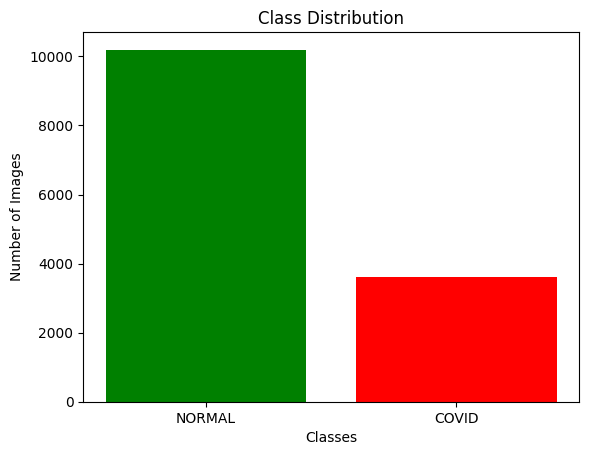

Number of Healthy images: 10192
Number of Pneumonia images: 3616


In [ ]:
# Count the number of images in each class
healthy_count = len(normal_files)
pneumonia_count = len(covid_labels)

# Create a histogram
plt.bar(['NORMAL', 'COVID'], [healthy_count, pneumonia_count], color=['green', 'red'])
plt.title('Class Distribution')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.show()
# Afficher le nombre d'images dans chaque classe
print(f"Number of Healthy images: {healthy_count}")
print(f"Number of Pneumonia images: {pneumonia_count}")

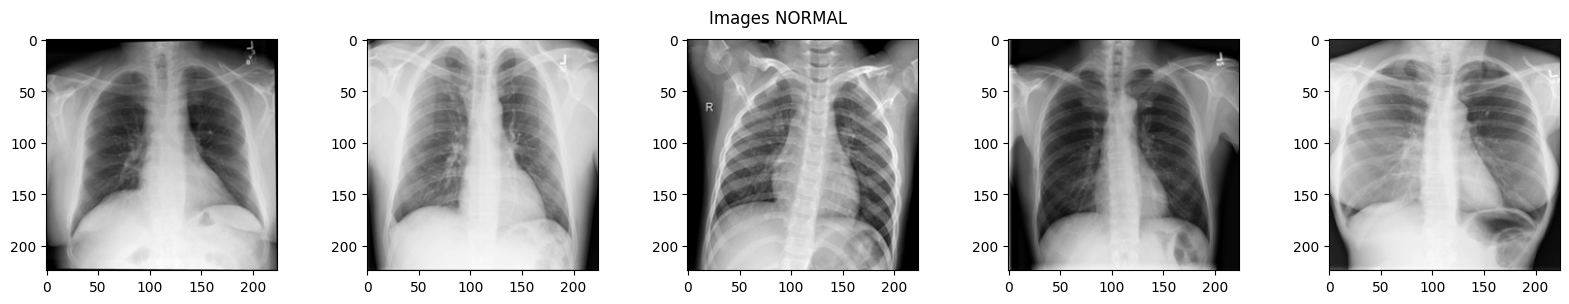

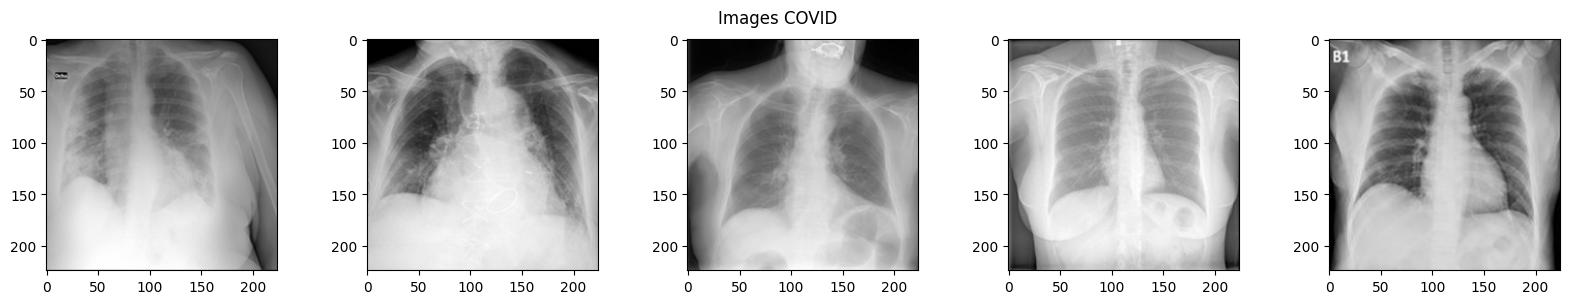

In [ ]:
def display_images(filepaths, title, num_images=5, img_size=(224, 224)):
    plt.figure(figsize=(20, 3))
    plt.suptitle(title)

    for i in range(num_images):
        img_path = random.choice(filepaths)
        img = Image.open(img_path).resize(img_size)  # Redimensionner l'image
        plt.subplot(1, num_images, i+1)
        plt.imshow(img, cmap='gray')#Affiche l’image en niveaux de gris.
        plt.axis('on')

    plt.show()

display_images(normal_files, "Images NORMAL")
display_images(covid_files, "Images COVID")

In [11]:
train_files, test_files, train_labels, test_labels = train_test_split(
    filepaths, labels, test_size=0.2, random_state=42, stratify=labels
)


In [12]:
train_files, val_files, train_labels, val_labels = train_test_split(
    train_files, train_labels, test_size=0.1, random_state=42, stratify=train_labels
)


In [13]:
print(f"Train : {len(train_files)}, Val : {len(val_files)}, Test : {len(test_files)}")


Train : 9941, Val : 1105, Test : 2762


In [14]:
print(len(train_files))
print(len(test_files))
print(len(val_files))

9941
2762
1105


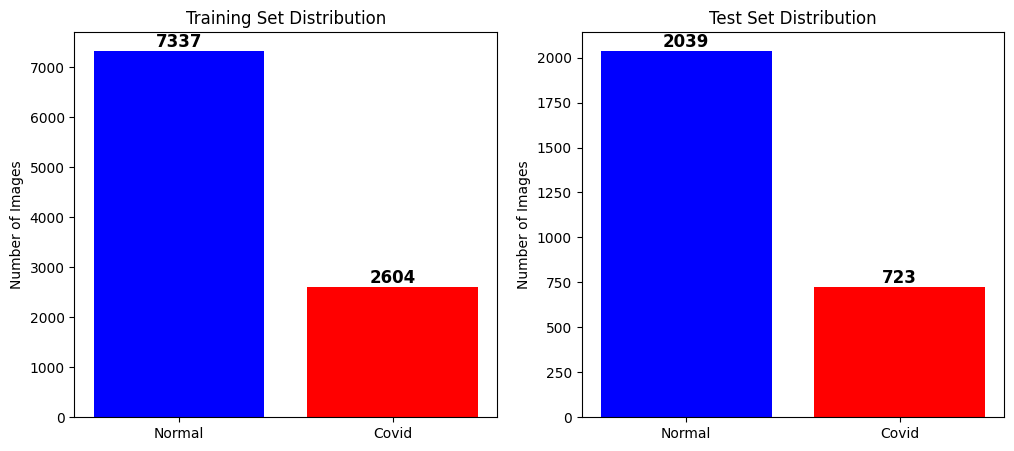

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert labels to NumPy array for easier processing
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

# Count the occurrences of each class (assuming 0 = Normal, 1 = Pneumonia)
train_counts = np.bincount(train_labels)
test_counts = np.bincount(test_labels)

# Define class names
class_names = ["Normal", "Covid"]

# Plot histogram
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Training set histogram
bars_train = ax[0].bar(class_names, train_counts, color=['blue', 'red'])
ax[0].set_title("Training Set Distribution")
ax[0].set_ylabel("Number of Images")

# Test set histogram
bars_test = ax[1].bar(class_names, test_counts, color=['blue', 'red'])
ax[1].set_title("Test Set Distribution")
ax[1].set_ylabel("Number of Images")

# Add labels on top of the bars
for bar in bars_train:
    ax[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{int(bar.get_height())}',
               ha='center', va='bottom', fontsize=12, fontweight='bold')

for bar in bars_test:
    ax[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{int(bar.get_height())}',
               ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

In [ ]:
#Flip horizontal aléatoire
image_path1 = '/content/chest_xray/chest_xray/train/PNEUMONIA/person1000_bacteria_2931.jpeg'
image1 = tf.io.read_file(image_path1)  # Read the image file
image1 = tf.image.decode_jpeg(image1, channels=3)  # Decode the image into a tensor
left_right1 = tf.image.random_flip_left_right(image1)
image_path2 = '/content/chest_xray/chest_xray/train/NORMAL/IM-0115-0001.jpeg'
image2 = tf.io.read_file(image_path2)  # Read the image file
image2 = tf.image.decode_jpeg(image2, channels=3)  # Decode the image into a tensor
left_right2 = tf.image.random_flip_left_right(image2)


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image1.numpy().astype(int))  # Convert to NumPy array and display
plt.title('Original Image(pneumonia)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(left_right1.numpy().astype(int))  # Display rot1 instead of rot
plt.title('Augmented Image(pneumonia)')
plt.axis('off')

plt.show()
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image2.numpy().astype(int))  # Convert to NumPy array and display
plt.title('Original Image(normal)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(left_right2.numpy().astype(int))  # Convert to NumPy array and display
plt.title('Augmented Image(normal)')
plt.axis('off')

plt.show()

NotFoundError: {{function_node __wrapped__ReadFile_device_/job:localhost/replica:0/task:0/device:CPU:0}} /content/chest_xray/chest_xray/train/PNEUMONIA/person1000_bacteria_2931.jpeg; No such file or directory [Op:ReadFile]

In [ ]:
#Modification de la luminosité
image_path1 = '/content/chest_xray/chest_xray/train/PNEUMONIA/person1000_bacteria_2931.jpeg'
image1 = tf.io.read_file(image_path1)  # Read the image file
image1 = tf.image.decode_jpeg(image1, channels=3)  # Decode the image into a tensor
bright1 = tf.image.random_brightness(image1, max_delta=0.2)
image_path2 = '/content/chest_xray/chest_xray/train/NORMAL/IM-0115-0001.jpeg'
image2 = tf.io.read_file(image_path2)  # Read the image file
image2 = tf.image.decode_jpeg(image2, channels=3)  # Decode the image into a tensor
bright2 = tf.image.random_brightness(image2, max_delta=0.2)


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image1.numpy().astype(int))  # Convert to NumPy array and display
plt.title('Original Image(pneumonia)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(bright1.numpy().astype(int))  # Display rot1 instead of rot
plt.title('Augmented Image(pneumonia)')
plt.axis('off')

plt.show()
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image2.numpy().astype(int))  # Convert to NumPy array and display
plt.title('Original Image(normal)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(bright2.numpy().astype(int))  # Convert to NumPy array and display
plt.title('Augmented Image(normal)')
plt.axis('off')

plt.show()

In [ ]:
#rotation
image_path1 = '/content/chest_xray/chest_xray/train/PNEUMONIA/person1000_bacteria_2931.jpeg'
image1 = tf.io.read_file(image_path1)  # Read the image file
image1 = tf.image.decode_jpeg(image1, channels=3)  # Decode the image into a tensor
angles = tf.random.uniform(shape=[], minval=-0.2, maxval=0.2)  # Rotation entre -15° et 15° (en radians)
rot1 = tfa.image.rotate(image1, angles)
image_path2 = '/content/chest_xray/chest_xray/train/NORMAL/IM-0115-0001.jpeg'
image2 = tf.io.read_file(image_path2)  # Read the image file
image2 = tf.image.decode_jpeg(image2, channels=3)  # Decode the image into a tensor
angles = tf.random.uniform(shape=[], minval=-0.2, maxval=0.2)  # Rotation entre -10° et 10° (en radians)
rot2 = tfa.image.rotate(image2, angles)


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image1.numpy().astype(int))  # Convert to NumPy array and display
plt.title('Original Image(pneumonia)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rot1.numpy().astype(int))  # Display rot1 instead of rot
plt.title('Augmented Image(pneumonia)')
plt.axis('off')

plt.show()
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image2.numpy().astype(int))  # Convert to NumPy array and display
plt.title('Original Image(normal)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rot2.numpy().astype(int))  # Convert to NumPy array and display
plt.title('Augmented Image(normal)')
plt.axis('off')

plt.show()

In [ ]:
#zoom
image_path1 = '/content/chest_xray/chest_xray/train/PNEUMONIA/person1000_bacteria_2931.jpeg'
image1 = tf.io.read_file(image_path1)  # Read the image file
image1 = tf.image.decode_jpeg(image1, channels=3)  # Decode the image into a tensor
zoom_factor = tf.random.uniform(shape=[], minval=1.0, maxval=1.2)
original_shape = tf.shape(image1)
new_shape = tf.cast(tf.cast(original_shape[:2], tf.float32) * zoom_factor, tf.int32) # Select only height and width
image11 = tf.image.resize(image1, new_shape)
image12 = tf.image.random_crop(image11, original_shape)
image_path2 = '/content/chest_xray/chest_xray/train/NORMAL/IM-0115-0001.jpeg'
image2 = tf.io.read_file(image_path2)  # Read the image file
image2 = tf.image.decode_jpeg(image2, channels=3)  # Decode the image into a tensor
zoom_factor = tf.random.uniform(shape=[], minval=1.0, maxval=1.2)
original_shape = tf.shape(image2)
new_shape = tf.cast(tf.cast(original_shape[:2], tf.float32) * zoom_factor, tf.int32) # Select only height and width
image22 = tf.image.resize(image2, new_shape)
image13 = tf.image.random_crop(image22, original_shape)


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image1.numpy().astype(int))  # Convert to NumPy array and display
plt.title('Original Image(pneumonia)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image12.numpy().astype(int))  # Display rot1 instead of rot
plt.title('Augmented Image(pneumonia)')
plt.axis('off')

plt.show()
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image2.numpy().astype(int))  # Convert to NumPy array and display
plt.title('Original Image(normal)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image13.numpy().astype(int))  # Convert to NumPy array and display
plt.title('Augmented Image(normal)')
plt.axis('off')

plt.show()

In [ ]:
def create_dataset(filepaths, labels, batch_size=32, augment=False):
    def load_and_preprocess_image(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, [224, 224])
        image = image / 255.0
        return image, label

    dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        def augment_image(image, label):
            image = tf.image.random_flip_left_right(image)
            image = tf.image.random_brightness(image, max_delta=0.2)
            angles = tf.random.uniform([], -0.2, 0.2)
            image = tfa.image.rotate(image, angles)
            zoom = tf.random.uniform([], 1.0, 1.2)
            shape = tf.shape(image)
            new_shape = tf.cast(tf.cast(shape[:2], tf.float32) * zoom, tf.int32)
            image = tf.image.resize(image, new_shape)
            image = tf.image.random_crop(image, shape)
            return image, label
        dataset = dataset.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)

    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_dataset = create_dataset(train_files, train_labels, augment=True)
val_dataset = create_dataset(val_files, val_labels)
test_dataset = create_dataset(test_files, test_labels)

In [ ]:
num_train_images = sum(1 for _ in train_dataset.unbatch())
num_val_images = sum(1 for _ in val_dataset.unbatch())
num_test_images = sum(1 for _ in test_dataset.unbatch())

print("Images Train (réelles après filtre) :", num_train_images)
print("Images Validation (réelles) :", num_val_images)
print("Images Test (réelles) :", num_test_images)


Images Train (réelles après filtre) : 9941
Images Validation (réelles) : 1105
Images Test (réelles) : 2762


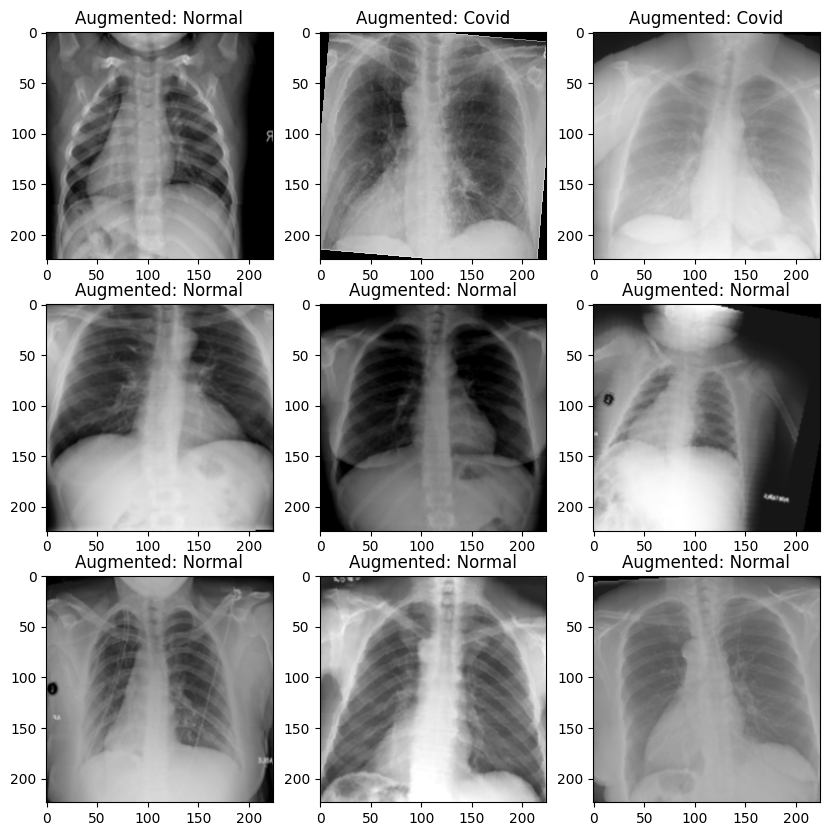

In [ ]:
import matplotlib.pyplot as plt

# Dictionnaire de correspondance des labels pour les deux classes
label_dict = {0: "Normal", 1: "Covid"}

# Prendre un batch d'images du dataset
for images, labels in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(min(9, len(images))):  # Afficher jusqu'à 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(f"Augmented: {label_dict[labels[i].numpy()]}")
        plt.axis("on")
    plt.show()

In [15]:
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Charger un modèle pré-entraîné (VGG19)
base_model = VGG19(include_top=False, input_shape=(224,224,3), weights='imagenet')

# Dégeler uniquement les 8 dernières couches
#for layer in base_model.layers[:-12]:  -- a tester

for layer in base_model.layers[:-2]:
    layer.trainable = False
for layer in base_model.layers[-2:]:
    layer.trainable = True

# Ajouter des couches personnalisées
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

# Créer le modèle final
model = Model(inputs=base_model.input, outputs=predictions)

# Compiler le modèle
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Afficher le résumé du modèle
model.summary()


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,155,969 (76.89 MB)

 Trainable params: 2,491,393 (9.50 MB)

 Non-trainable params: 17,664,576 (67.39 MB)

In [ ]:
for layer in model.layers:
   print(layer, layer.trainable== True)

<InputLayer name=input_layer, built=True> False
<Conv2D name=block1_conv1, built=True> False
<Conv2D name=block1_conv2, built=True> False
<MaxPooling2D name=block1_pool, built=True> False
<Conv2D name=block2_conv1, built=True> False
<Conv2D name=block2_conv2, built=True> False
<MaxPooling2D name=block2_pool, built=True> False
<Conv2D name=block3_conv1, built=True> False
<Conv2D name=block3_conv2, built=True> False
<Conv2D name=block3_conv3, built=True> False
<Conv2D name=block3_conv4, built=True> False
<MaxPooling2D name=block3_pool, built=True> False
<Conv2D name=block4_conv1, built=True> False
<Conv2D name=block4_conv2, built=True> False
<Conv2D name=block4_conv3, built=True> False
<Conv2D name=block4_conv4, built=True> False
<MaxPooling2D name=block4_pool, built=True> False
<Conv2D name=block5_conv1, built=True> False
<Conv2D name=block5_conv2, built=True> False
<Conv2D name=block5_conv3, built=True> False
<Conv2D name=block5_conv4, built=True> True
<MaxPooling2D name=block5_pool, b

In [ ]:
# ============================================================
# ⚖️ Calcul des poids de classes pour équilibrer le dataset
# ============================================================
from sklearn.utils import class_weight

# Convertir les labels en numpy array
train_labels_np = np.array(train_labels)

# Calcul automatique des poids
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_np),
    y=train_labels_np
)

# Dictionnaire pour TensorFlow
class_weights = {i: w for i, w in enumerate(class_weights)}
print("Class weights:", class_weights)



Class weights: {0: np.float64(0.6774567261823634), 1: np.float64(1.908794162826421)}


**Exercice** : Écrivez un code TensorFlow/Keras pour entraîner un modèle CNN (VGG19) sur le jeu de données d’images (train_files et val_dataset) en utilisant des callbacks afin de :

-Arrêter automatiquement l’entraînement lorsque la performance sur les données de validation cesse de s’améliorer.

-Sauvegarder uniquement la version du modèle ayant obtenu la meilleure performance sur la validation.

Instructions :

- Utilisez EarlyStopping pour surveiller la perte de validation (val_loss) et restaurer les meilleurs poids.

- Utilisez ModelCheckpoint pour sauvegarder le meilleur modèle dans un fichier nommé 'best_modelVGG19.keras'.

- Entraînez le modèle sur un maximum de 50 époques avec les callbacks activés.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=4,          # Stop after 5 epochs with no improvement
    restore_best_weights=True # Restore best weights from the epoch with the lowest val_loss
)

model_checkpoint = ModelCheckpoint(
    filepath='best_modelVGG19.keras', # Save the best model to this file
    monitor='val_loss',      # Monitor validation loss
    save_best_only=True,      # Save only the best model
    mode='min',
    verbose=1
)

# Entraîner le modèle
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=[early_stopping, model_checkpoint], # Added model_checkpoint callback
    class_weight=class_weights,                     # <-- ajout ici

    verbose=1
)

Epoch 1/50
311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.6926 - loss: 0.5789
Epoch 1: val_loss improved from inf to 0.36033, saving model to best_modelVGG19.keras
311/311 ━━━━━━━━━━━━━━━━━━━━ 114s 312ms/step - accuracy: 0.6928 - loss: 0.5787 - val_accuracy: 0.8543 - val_loss: 0.3603
Epoch 2/50
311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.7943 - loss: 0.4308
Epoch 2: val_loss improved from 0.36033 to 0.28792, saving model to best_modelVGG19.keras
311/311 ━━━━━━━━━━━━━━━━━━━━ 78s 251ms/step - accuracy: 0.7944 - loss: 0.4307 - val_accuracy: 0.8950 - val_loss: 0.2879
Epoch 3/50
311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.8251 - loss: 0.3797
Epoch 3: val_loss improved from 0.28792 to 0.24706, saving model to best_modelVGG19.keras
311/311 ━━━━━━━━━━━━━━━━━━━━ 82s 251ms/step - accuracy: 0.8251 - loss: 0.3797 - val_accuracy: 0.9032 - val_loss: 0.2471
Epoch 4/50
311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.8462 - loss: 0.3383
Epoch 4: val_loss imp

In [ ]:
from google.colab import files
files.download("best_modelVGG19.keras")
model.save("best_modelVGG19_2.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

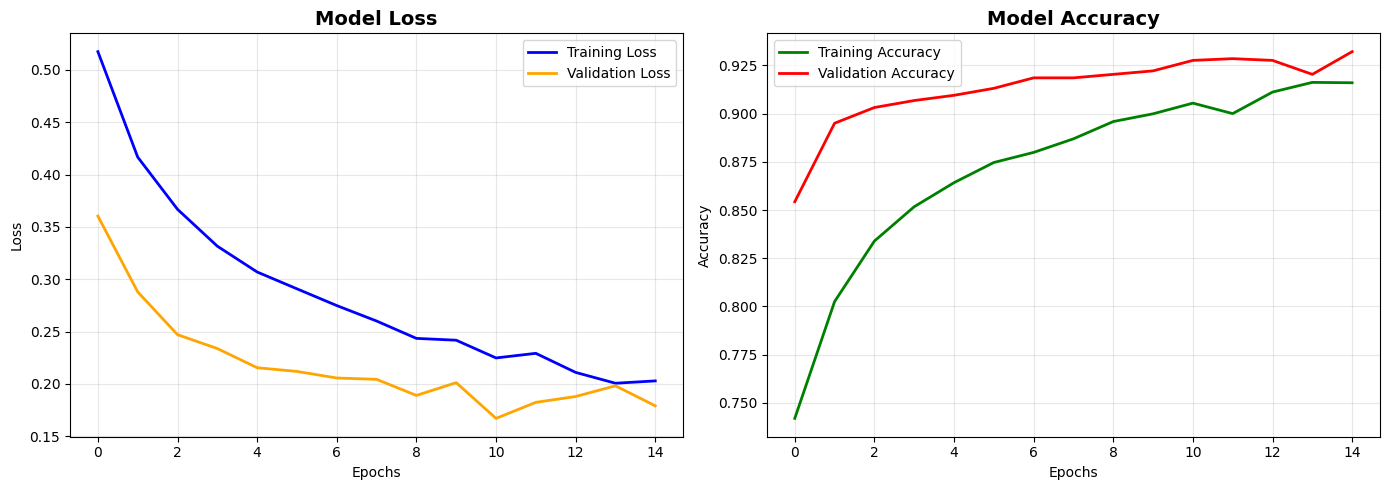

In [ ]:
import matplotlib.pyplot as plt

# --- Afficher les courbes de loss et d'accuracy ---
plt.figure(figsize=(14, 5))

# === Courbe de Loss ===
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# === Courbe d'Accuracy ===
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='green', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2)
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Ajuster l'espacement
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import load_model

# Charger le meilleur modèle sauvegardé
best_model = load_model('best_modelVGG19.keras')

# Vérifier l'époque où la val_loss était minimale
best_val_loss = min(history.history['val_loss'])
best_epoch = history.history['val_loss'].index(best_val_loss) + 1
print(f"Meilleur modèle à l'époque {best_epoch} avec val_loss = {best_val_loss:.4f}")


Meilleur modèle à l'époque 11 avec val_loss = 0.1671


In [ ]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Get predictions on the test set
predictions = model.predict(test_dataset)
predicted_classes = (predictions > 0.5).astype("int32") # Convert probabilities to class labels

# Afficher le rapport de classification avec 4 chiffres après la virgule
print("Classification Report:")
print(classification_report(test_labels, predicted_classes, digits=4))

# Calculer et afficher les métriques globales
accuracy = accuracy_score(test_labels, predicted_classes)
precision = precision_score(test_labels, predicted_classes)
recall = recall_score(test_labels, predicted_classes)
f1 = f1_score(test_labels, predicted_classes)

print("\nGlobal Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

87/87 ━━━━━━━━━━━━━━━━━━━━ 26s 292ms/step
Classification Report:
              precision    recall  f1-score   support

           0     0.9497    0.9534    0.9515      2039
           1     0.8671    0.8575    0.8623       723

    accuracy                         0.9283      2762
   macro avg     0.9084    0.9055    0.9069      2762
weighted avg     0.9281    0.9283    0.9282      2762


Global Metrics:
Accuracy: 0.9283
Precision: 0.8671
Recall: 0.8575
F1 Score: 0.8623


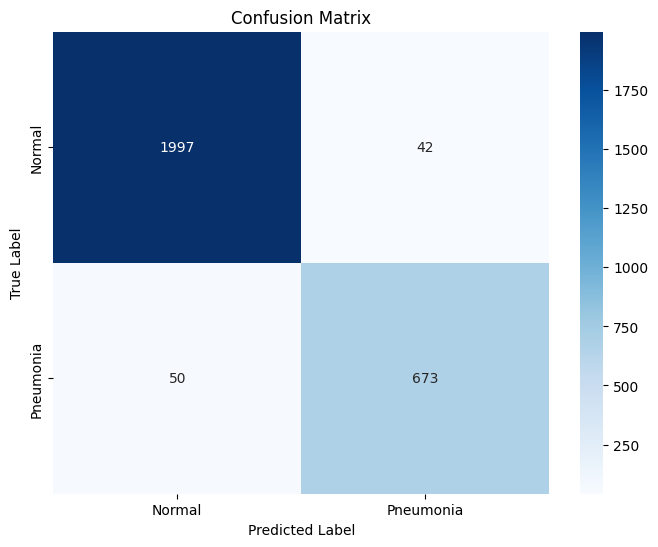

In [ ]:
# Matrice de confusion
cm = confusion_matrix(test_labels, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [16]:
#-------------------------------------------------VGG avec poids aleatoire---------------------------#


# Charger un modèle pré-entraîné (VGG19)
base_model = VGG19(include_top=False, input_shape=(224,224,3), weights=None)

for layer in base_model.layers:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,155,969 (76.89 MB)

 Trainable params: 20,155,969 (76.89 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=5,          # Stop after 5 epochs with no improvement
    restore_best_weights=True # Restore best weights from the epoch with the lowest val_loss
)

model_checkpoint = ModelCheckpoint(
    filepath='best_modelVGG19_random.keras', # Save the best model to this file
    monitor='val_loss',      # Monitor validation loss
    save_best_only=True,      # Save only the best model
    mode='min',
    verbose=1
)

# Entraîner le modèle
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=[early_stopping, model_checkpoint], # Added model_checkpoint callback
    verbose=1
)

NameError: name 'train_dataset' is not defined

In [ ]:
import matplotlib.pyplot as plt

# --- Afficher les courbes de loss et d'accuracy ---
plt.figure(figsize=(14, 5))

# === Courbe de Loss ===
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# === Courbe d'Accuracy ===
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='green', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2)
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Ajuster l'espacement
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Get predictions on the test set
predictions = model.predict(test_dataset)
predicted_classes = (predictions > 0.5).astype("int32") # Convert probabilities to class labels

# Afficher le rapport de classification avec 4 chiffres après la virgule
print("Classification Report:")
print(classification_report(test_labels, predicted_classes, digits=4))

# Calculer et afficher les métriques globales
accuracy = accuracy_score(test_labels, predicted_classes)
precision = precision_score(test_labels, predicted_classes)
recall = recall_score(test_labels, predicted_classes)
f1 = f1_score(test_labels, predicted_classes)

print("\nGlobal Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

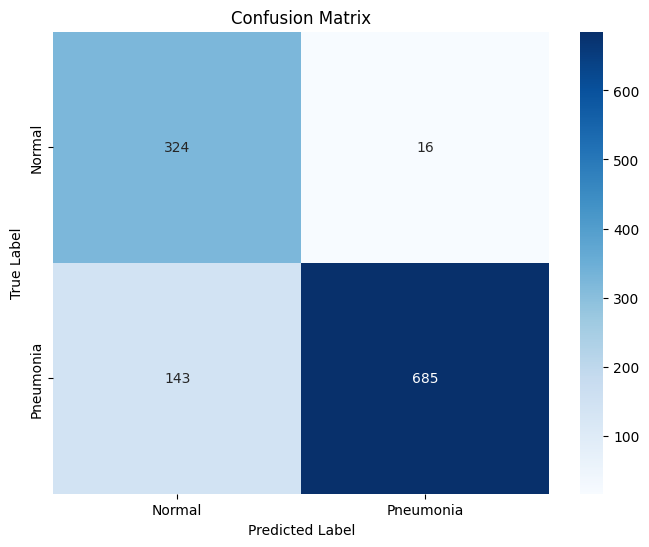

In [ ]:
# Matrice de confusion
cm = confusion_matrix(test_labels, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ==========================
# Charger ResNet50V2 pré-entraîné
# ==========================
base_model = ResNet50V2(
    include_top=False,
    input_shape=(224,224,3),
    weights='imagenet'
)

# ==========================
# Fine-tuning des dernières couches
# ==========================
for layer in base_model.layers[:-10]:
    layer.trainable = False
for layer in base_model.layers[-10:]:
    layer.trainable = True

# ==========================
# Ajouter couches personnalisées
# ==========================
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)  # Classification binaire

model = Model(inputs=base_model.input, outputs=predictions)

# ==========================
# Compiler modèle
# ==========================
model.compile(
    optimizer=Adam(learning_rate=1e-4),  # léger learning rate
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==========================
# Class weights si dataset déséquilibré
# ==========================
train_labels_np = np.array(train_labels)
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_np),
    y=train_labels_np
)
class_weights = {i: w for i, w in enumerate(class_weights)}
print("Class weights:", class_weights)

# ==========================
# Callbacks
# ==========================
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    filepath='best_modelResNet50V2.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# ==========================
# Entraînement
# ==========================
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=[early_stopping, model_checkpoint],
    class_weight=class_weights,
    verbose=1
)


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_10[0… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 23,827,713 (90.90 MB)

 Trainable params: 3,678,721 (14.03 MB)

 Non-trainable params: 20,148,992 (76.86 MB)

Class weights: {0: np.float64(0.6774567261823634), 1: np.float64(1.908794162826421)}
Epoch 1/50
311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.7380 - loss: 0.5159
Epoch 1: val_loss improved from inf to 0.21014, saving model to best_modelResNet50V2.keras
311/311 ━━━━━━━━━━━━━━━━━━━━ 80s 208ms/step - accuracy: 0.7381 - loss: 0.5156 - val_accuracy: 0.9186 - val_loss: 0.2101
Epoch 2/50
311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.8621 - loss: 0.3159
Epoch 2: val_loss improved from 0.21014 to 0.17146, saving model to best_modelResNet50V2.keras
311/311 ━━━━━━━━━━━━━━━━━━━━ 57s 150ms/step - accuracy: 0.8621 - loss: 0.3159 - val_accuracy: 0.9376 - val_loss: 0.1715
Epoch 3/50
311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.8940 - loss: 0.2527
Epoch 3: val_loss improved from 0.17146 to 0.13463, saving model to best_modelResNet50V2.keras
311/311 ━━━━━━━━━━━━━━━━━━━━ 51s 163ms/step - accuracy: 0.8940 - loss: 0.2527 - val_accuracy: 0.9457 - val_loss: 0.1346
Epoch 4/50

In [ ]:
import math
nb_images = len(list(test_dataset.unbatch()))
print("Nombre total d’images :", nb_images)


Nombre total d’images : 2762


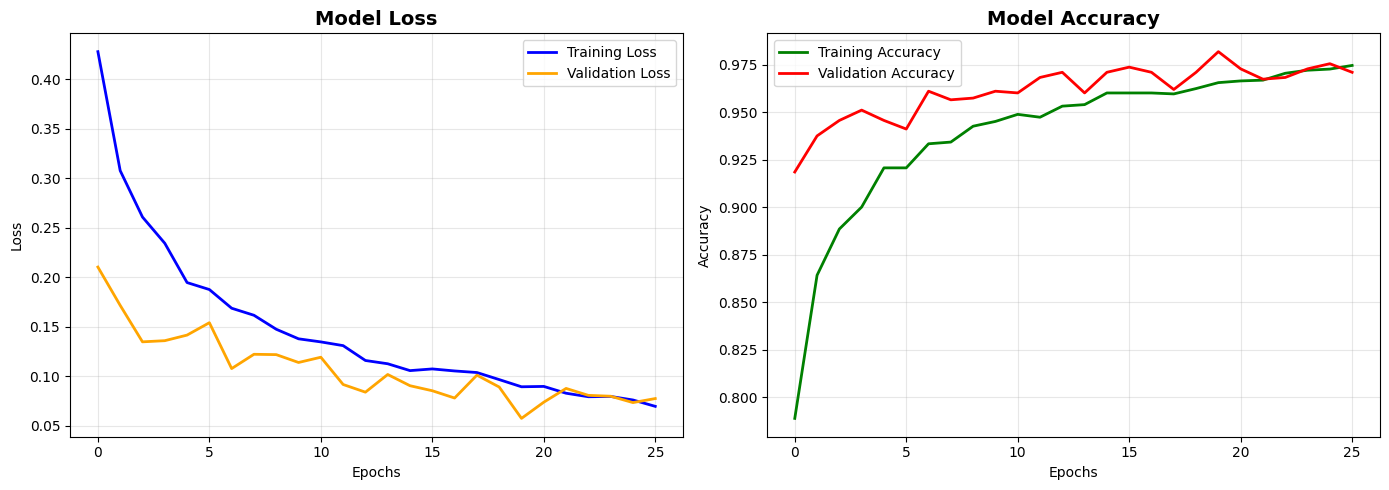

In [ ]:
import matplotlib.pyplot as plt

# --- Afficher les courbes de loss et d'accuracy ---
plt.figure(figsize=(14, 5))

# === Courbe de Loss ===
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# === Courbe d'Accuracy ===
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='green', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2)
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Ajuster l'espacement
plt.tight_layout()
plt.show()

In [ ]:
# Nombre d'exemples dans le dataset d'entraînement
train_size = sum(1 for _ in train_dataset)
print(f"Nombre d'exemples dans le train_dataset : {train_size}")

# Nombre d'exemples dans le dataset de validation
val_size = sum(1 for _ in val_dataset)
print(f"Nombre d'exemples dans le val_dataset : {val_size}")


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Get predictions on the test set
predictions = model.predict(test_dataset)
predicted_classes = (predictions > 0.5).astype("int32") # Convert probabilities to class labels

# Afficher le rapport de classification avec 4 chiffres après la virgule
print("Classification Report:")
print(classification_report(test_labels, predicted_classes, digits=4))

# Calculer et afficher les métriques globales
accuracy = accuracy_score(test_labels, predicted_classes)
precision = precision_score(test_labels, predicted_classes)
recall = recall_score(test_labels, predicted_classes)
f1 = f1_score(test_labels, predicted_classes)

print("\nGlobal Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

87/87 ━━━━━━━━━━━━━━━━━━━━ 17s 164ms/step
Classification Report:
              precision    recall  f1-score   support

           0     0.9756    0.9794    0.9775      2039
           1     0.9413    0.9308    0.9360       723

    accuracy                         0.9667      2762
   macro avg     0.9584    0.9551    0.9568      2762
weighted avg     0.9666    0.9667    0.9666      2762


Global Metrics:
Accuracy: 0.9667
Precision: 0.9413
Recall: 0.9308
F1 Score: 0.9360


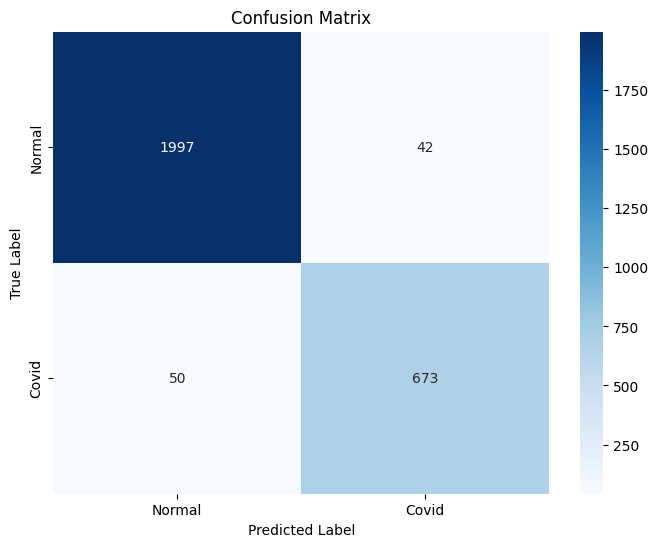

In [ ]:
# Matrice de confusion
cm = confusion_matrix(test_labels, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Covid'], yticklabels=['Normal', 'Covid'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.utils import class_weight
base_model = MobileNetV3Large(
    include_top=False,
    input_shape=(224, 224, 3),
    weights='imagenet'
)

# 🔒 Geler les couches (on garde juste les dernières dégelées pour fine-tuning)
for layer in base_model.layers[:-20]:
    layer.trainable = False
for layer in base_model.layers[-20:]:
    layer.trainable = True

# ============================================================
# 🧩 3. Ajouter des couches personnalisées
# ============================================================
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# ============================================================
# ⚖️ 4. Calcul des poids de classes
# ============================================================
train_labels_np = np.array(train_labels)
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_np),
    y=train_labels_np
)
class_weights = {i: w for i, w in enumerate(class_weights)}
print("Class weights:", class_weights)

# ============================================================
# ⚙️ 5. Compilation du modèle
# ============================================================
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

# ============================================================
# ⏱️ 6. Callbacks (Early Stopping + Checkpoint)
# ============================================================
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath='best_model_MobileNetV3.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# ============================================================
# 🚀 7. Entraînement
# ============================================================
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=[early_stopping, checkpoint],
    class_weight=class_weights,
    verbose=1
)


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


NameError: name 'train_labels' is not defined

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --- Charger le modèle pré-entraîné EfficientNetV2 ---
base_model = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    input_shape=(224, 224, 3),
    weights='imagenet'

)
base_model.trainable = False


# --- Couches personnalisées ---
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
predictions = layers.Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)


# --- Compilation ---
model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# --- Callbacks ---
early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model_EfficientNet.keras', monitor='val_loss', save_best_only=True, verbose=1)

# --- Entraînement ---
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)


Epoch 1/50
311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.7308 - loss: 0.5902
Epoch 1: val_loss improved from inf to 0.57538, saving model to best_model_EfficientNet.keras
311/311 ━━━━━━━━━━━━━━━━━━━━ 96s 225ms/step - accuracy: 0.7308 - loss: 0.5902 - val_accuracy: 0.7385 - val_loss: 0.5754
Epoch 2/50
311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.7359 - loss: 0.5826
Epoch 2: val_loss improved from 0.57538 to 0.57477, saving model to best_model_EfficientNet.keras
311/311 ━━━━━━━━━━━━━━━━━━━━ 48s 154ms/step - accuracy: 0.7359 - loss: 0.5825 - val_accuracy: 0.7385 - val_loss: 0.5748
Epoch 3/50
311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.7359 - loss: 0.5824
Epoch 3: val_loss improved from 0.57477 to 0.57320, saving model to best_model_EfficientNet.keras
311/311 ━━━━━━━━━━━━━━━━━━━━ 49s 158ms/step - accuracy: 0.7359 - loss: 0.5824 - val_accuracy: 0.7385 - val_loss: 0.5732
Epoch 4/50
311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.7359 - loss: 0.582

NameError: name 'history' is not defined

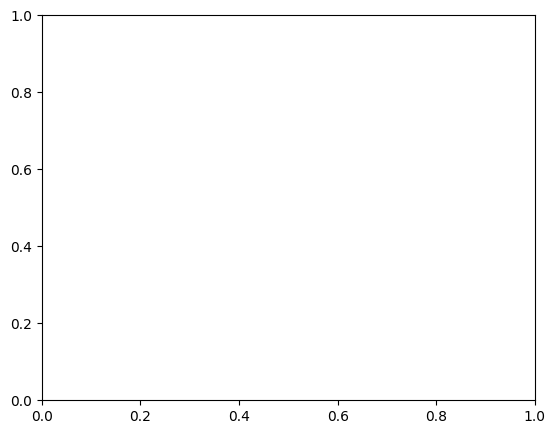

In [ ]:
import matplotlib.pyplot as plt

# --- Afficher les courbes de loss et d'accuracy ---
plt.figure(figsize=(14, 5))

# === Courbe de Loss ===
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# === Courbe d'Accuracy ===
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='green', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2)
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Ajuster l'espacement
plt.tight_layout()
plt.show()

NameError: name 'history' is not defined

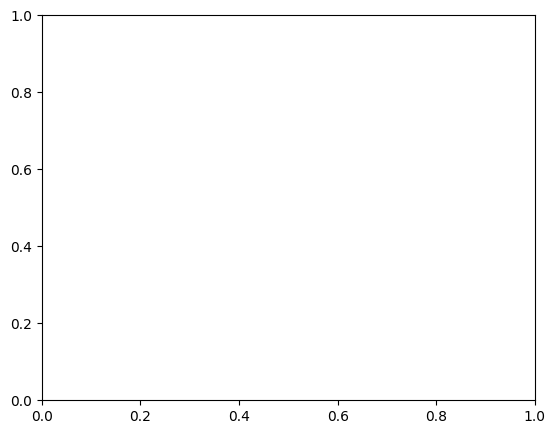

In [ ]:
import matplotlib.pyplot as plt

# --- Afficher les courbes de loss et d'accuracy ---
plt.figure(figsize=(14, 5))

# === Courbe de Loss ===
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# === Courbe d'Accuracy ===
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='green', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2)
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Ajuster l'espacement
plt.tight_layout()
plt.show()

In [ ]:
#Tester d'autres modèles de deep learning ViT, CNN... en utilisant le fine tuning